## Учебная модель прогноза по больным диабетом
<a id="title"></a>
### Оглавление:
- [Анализ данных](#analysis)
- [1 признак](#1)
- [2 признака](#2)
- [4 признака](#4)
- [6 признаков](#6)
- [Финальный график](#final)


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


Загружаем данные по диабету

In [28]:
bunch = load_diabetes(as_frame=True, scaled=False)
diabetes_df = bunch.data      # DataFrame, 10 признаков
y = bunch.target    # Series, целевая переменная

diabetes_df — это DataFrame содержащий данные по больным диабетом, состоящий из 10 столбцов (признаков).

Информация о колонках:
- **age**, возраст в годах
- **sex**, пол
- **bmi**, ИМТ (индекс массы тела)
- **bp**, среднее артериальное давление
- **s1 tc**, общий холестерин сыворотки
- **s2 ldl**, липопротеины низкой плотности
- **s3 hdl**, липопротеины высокой плотности
- **s4 tch**, общий холестерин / HDL
- **s5 ltg**, логарифм уровня триглицеридов в сыворотке крови
- **s6 glu**, уровень глюкозы в крови

In [29]:
diabetes_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.00,157.0,93.2,38.0,4.00,4.8598,87.0
1,48.0,1.0,21.6,87.00,183.0,103.2,70.0,3.00,3.8918,69.0
2,72.0,2.0,30.5,93.00,156.0,93.6,41.0,4.00,4.6728,85.0
3,24.0,1.0,25.3,84.00,198.0,131.4,40.0,5.00,4.8903,89.0
4,50.0,1.0,23.0,101.00,192.0,125.4,52.0,4.00,4.2905,80.0
...,...,...,...,...,...,...,...,...,...,...
437,60.0,2.0,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0
438,47.0,2.0,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0


<a id="analysis"></a>
### Анализ данных

[Оглавление](#'title')

In [30]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [31]:
diabetes_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,48.518100,13.109028,19.0000,38.2500,50.00000,59.0000,79.000
sex,442.0,1.468326,0.499561,1.0000,1.0000,1.00000,2.0000,2.000
bmi,442.0,26.375792,4.418122,18.0000,23.2000,25.70000,29.2750,42.200
bp,442.0,94.647014,13.831283,62.0000,84.0000,93.00000,105.0000,133.000
s1,442.0,189.140271,34.608052,97.0000,164.2500,186.00000,209.7500,301.000
s2,442.0,115.439140,30.413081,41.6000,96.0500,113.00000,134.5000,242.400
s3,442.0,49.788462,12.934202,22.0000,40.2500,48.00000,57.7500,99.000
s4,442.0,4.070249,1.290450,2.0000,3.0000,4.00000,5.0000,9.090
s5,442.0,4.641411,0.522391,3.2581,4.2767,4.62005,4.9972,6.107
s6,442.0,91.260181,11.496335,58.0000,83.2500,91.00000,98.0000,124.000


Данные выглядят корректными, пропуски отсутствуют, аномальные значения и выбросы не выявлены.

y — это target, целевые значения будущей модели.

Представляет собой количественную оценку прогрессирования заболевания через год после исходного состояния.

In [32]:
y

0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: target, Length: 442, dtype: float64

In [33]:
y.describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

Смотрим взаимосвязи между признаками:

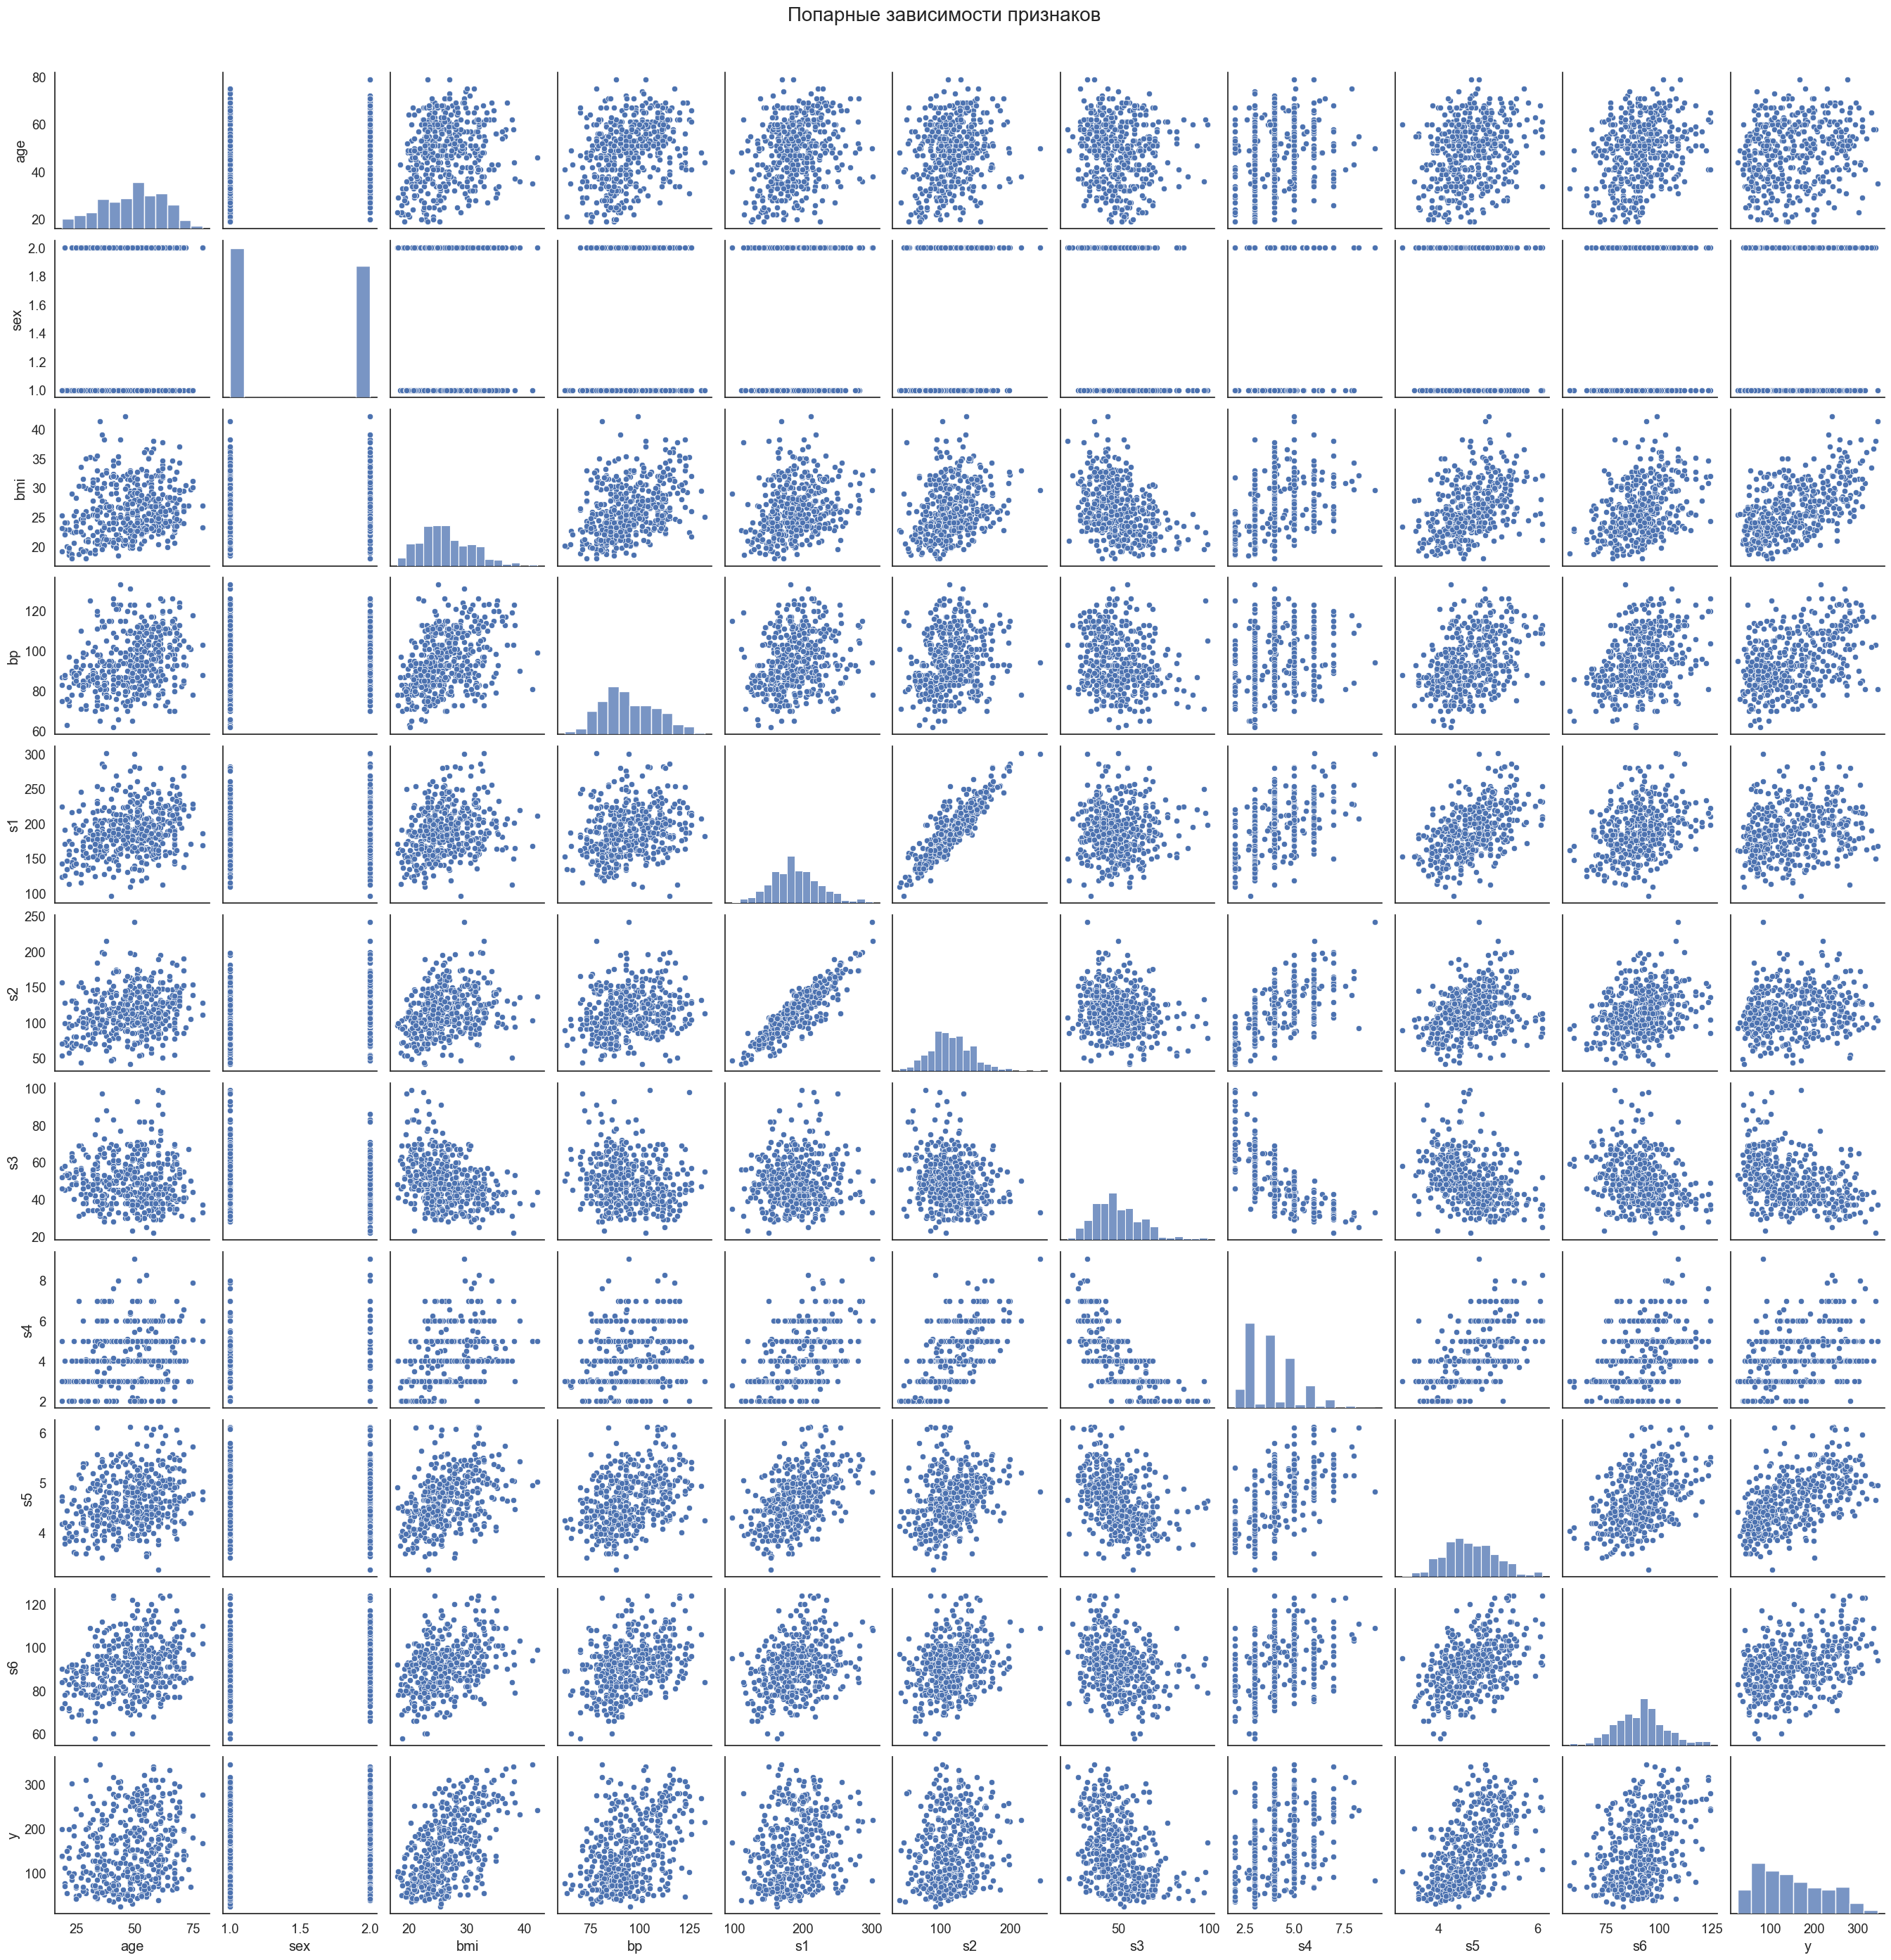

In [34]:
diabetes_df['y'] = y
sns.set_theme(style="white", font_scale=1.2)
sns.pairplot(diabetes_df.select_dtypes(include='number'))
plt.suptitle("Попарные зависимости признаков", y=1.02, fontsize=20)
plt.show()

Смотрим на последнюю строчку с целевым показателем y.

Можно выделить 2 основных показателя с сильной прямой положительной связью: 
- **bmi** (индекс массы тела);
- **s5** (логарифм уровня триглицеридов в сыворотке крови).
  
Также среднюю прямую положительную связь имеет:
- **bp** (среднее артериальное давление).

Параметр **s4** (общий холестерин / HDL) имеет много однотипных данных. На графике мы видим точки выстроенные по прямым линиям. Посмотрим на этот параметр поближе.

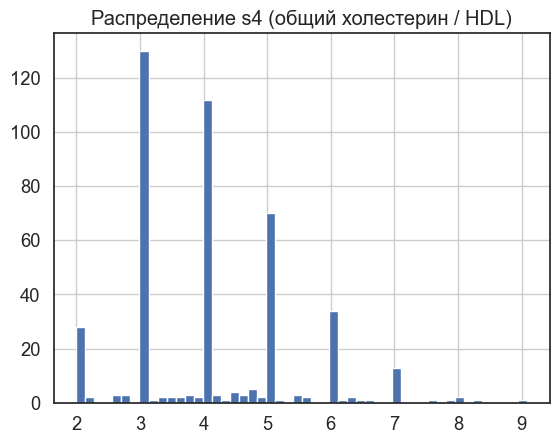

In [35]:
diabetes_df['s4'].hist(bins=50)
plt.title('Распределение s4 (общий холестерин / HDL)')
plt.show()

Скорее всего, "расческа" на графике s4 — это артефакт округления исходных данных.

Рассчитаем корреляцию с помощью метода Phik, так как признак **sex** (пол) является категориальным и **s4** (общий холестерин / HDL) похож на категориальный. К ним нельзя применять модель Спирмена.

In [36]:
from phik import resources, report

In [37]:
phik_columns = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'y']
phik_matrix = diabetes_df[phik_columns].phik_matrix(interval_cols=['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'y'])
phik_matrix["y"]

age    0.124114
sex    0.000000
bmi    0.599474
bp     0.477829
s1     0.215325
s2     0.198411
s3     0.416668
s4     0.480957
s5     0.554885
s6     0.337334
y      1.000000
Name: y, dtype: float64

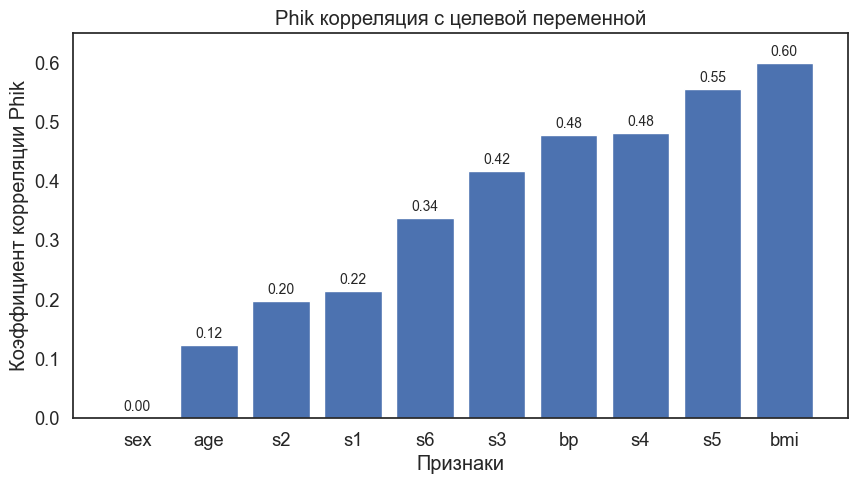

In [38]:
# Сортируем Phik корреляции
corr_phik_with_target = phik_matrix["y"].sort_values()

# удаляем корреляцию целевой переменной с самой собой
corr_phik_with_target = corr_phik_with_target.drop("y")

# строим столбчатую диаграмму корреляций
plt.figure(figsize=(10, 5))
bars = plt.bar(corr_phik_with_target.index, corr_phik_with_target.values)
plt.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
plt.title("Phik корреляция с целевой переменной")
plt.xlabel("Признаки")
plt.ylabel("Коэффициент корреляции Phik")
plt.ylim(0, corr_phik_with_target.values.max() + 0.05)
plt.show()

<a id="1"></a>
## 1 признак

[Оглавление](#'title')

Построим модель на основе 1 признака с самой высокой корреляцией к целевым показателям:
- **bmi**, ИМТ (индекс массы тела), корреляция 0,6.

Делим данные на train и test. Из-за невысокой выборкой, всего 442 строки, меняем соотношение между train и test с 75/25 на 80/20.

In [83]:
train_idx, test_idx = train_test_split(diabetes_df.index, random_state=42, test_size=0.20)

Фиксируем таргет train и таргет test.

In [84]:
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

In [85]:
# 1 признак
features_1 = [
    "bmi",
]

X_1_f_train = diabetes_df.loc[train_idx, features_1]
X_1_f_test = diabetes_df.loc[test_idx, features_1]

Пробуем применить модель.

In [86]:
# 1 признак
reg_1_features = LinearRegression()
reg_1_features.fit(X_1_f_train, y_train)

y_train_pred = reg_1_features.predict(X_1_f_train)
y_test_pred = reg_1_features.predict(X_1_f_test)

Смотрим коэффициенты и смещение

In [87]:
# 1 признак
print(f"Коэффициенты: {reg_1_features.coef_}")
print(f"Смещение:      {reg_1_features.intercept_:.4f}")

Коэффициенты: [10.7627909]
Смещение:      -131.8738


Оценим качество модели через R².

In [88]:
# 1 признак
r2_1_f_train = r2_score(y_train, y_train_pred)
r2_1_f_test = r2_score(y_test, y_test_pred)

print("✅ 1 признак")
print(f"R² train  : {r2_1_f_train:.4f}")
print(f"R² test   : {r2_1_f_test:.4f}")

✅ 1 признак
R² train  : 0.3657
R² test   : 0.2334


🔎 Модель построенная по 1 признаку получилась слабой, показав на тестовых данных 23% объяснения дисперсии, что не лучше, чем просто предсказывать среднее значение. При этом Коэффициент детерминации R² для данных train 0.3657 значительно выше чем для данных test 0.2334. Изменение параметра random_state для данных с небольшой выборкой при делении данных на train и test (всего 442 строки), по моим наблюдениям, приводит к значительной разнице между Коэффициентами детерминации R² для train и test, раскачивая маятник то в одну, то в другую сторону. Я выбрал пропорцию 80/20, что показало более близкие результаты между train и test в построении модели более чем с 1 признаком.

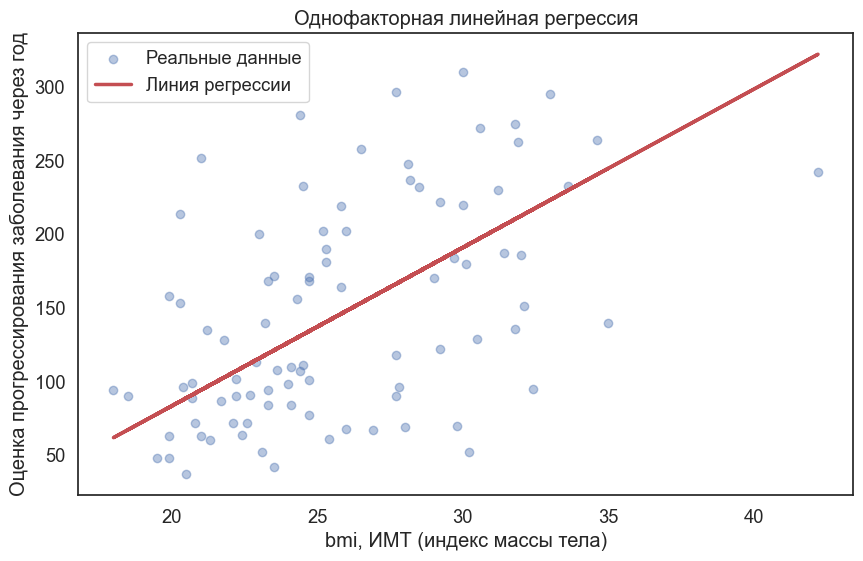

In [93]:

plt.figure(figsize=(10, 6))
plt.scatter(X_1_f_test, y_test, alpha=0.4, label="Реальные данные")
plt.plot(X_1_f_test, y_test_pred, "r-", linewidth=2.5, label="Линия регрессии")
plt.xlabel("bmi, ИМТ (индекс массы тела)")
plt.ylabel("Оценка прогрессирования заболевания через год")
plt.title("Однофакторная линейная регрессия")
plt.legend()
plt.show()

<a id="2"></a>
## 2 признака

[Оглавление](#'title')

Сделаем модель для двух основных признаков:
- **bmi**, ИМТ (индекс массы тела), корреляция 0,6; 
- **s5**, логарифм уровня триглицеридов в сыворотке крови, корреляция 0,55.

Извлекаем данные по 2 признакам

In [63]:
# 2 признака
features_2 = [
    "bmi",
    "s5",
]

X_2_f_train = diabetes_df.loc[train_idx, features_2]
X_2_f_test = diabetes_df.loc[test_idx, features_2]

Пробуем применить модель.

In [64]:
# 2 признака
reg_2_features = LinearRegression()
reg_2_features.fit(X_2_f_train, y_train)

y_train_pred = reg_2_features.predict(X_2_f_train)
y_test_pred = reg_2_features.predict(X_2_f_test)

Смотрим коэффициенты и смещение

In [65]:
# 2 признака
print(f"Коэффициенты: {reg_2_features.coef_}")
print(f"Смещение:      {reg_2_features.intercept_:.4f}")

Коэффициенты: [ 7.89075942 51.25033673]
Смещение:      -294.2167


Оценим качество модели через R².

In [67]:
# 2 признака
r2_2_f_train = r2_score(y_train, y_train_pred)
r2_2_f_test = r2_score(y_test, y_test_pred)

print("✅ 2 признака")
print(f"R² train  : {r2_2_f_train:.4f}")
print(f"R² test   : {r2_2_f_test:.4f}")

✅ 2 признака
R² train  : 0.4583
R² test   : 0.4523


🔎 Модель построенная по 2 признакам получилась слабой. При этом Коэффициент детерминации R² для данных train 0.4583 незначительно выше чем для данных test 0.4523. Изменение параметра random_state для данных с небольшой выборкой при делении данных на train и test (всего 442 строки), по моим наблюдениям, приводит к значительной разнице между Коэффициентами детерминации R² для train и test, раскачивая маятник то в одну, то в другую сторону. Я выбрал пропорцию 80/20, что показало более близкие результаты между train и test.

<a id="4"></a>
## 4 признака

[Оглавление](#'title')

Попробуем добавить 2 новых признака:
- **bp** (среднее артериальное давление), корреляция 0,48;
- **s4** (общий холестерин / HDL), корреляция 0,48.

In [68]:
# 4 признака
features_4 = [
    "bmi",
    "s5",
    "bp",
    "s4",
]

X_4_f_train = diabetes_df.loc[train_idx, features_4]
X_4_f_test = diabetes_df.loc[test_idx, features_4]

Делаем предсказание.

In [69]:
# 4 признака
reg_4_features = LinearRegression()
reg_4_features.fit(X_4_f_train, y_train)

y_train_pred = reg_4_features.predict(X_4_f_train)
y_test_pred = reg_4_features.predict(X_4_f_test)

Смотрим коэффициенты и смещение.

In [70]:
# 4 признака
print(f"Коэффициенты: {reg_4_features.coef_}")
print(f"Смещение:      {reg_4_features.intercept_:.4f}")

Коэффициенты: [ 6.81134405 40.35709134  0.99960345  3.3382212 ]
Смещение:      -323.4405


Считаем R<sup>2</sup>.

In [71]:
# 4 признака
r2_4_f_train = r2_score(y_train, y_train_pred)
r2_4_f_test = r2_score(y_test, y_test_pred)

print(f"R² train (4 признака): {r2_4_f_train:.4f}")
print(f"R² test (4 признака): {r2_4_f_test:.4f}")

R² train (4 признака): 0.4850
R² test (4 признака): 0.4526


Сравниваем R<sup>2</sup> с поправкой с предыдущими моделями.

In [75]:
# 4 признака
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


r2_adj_2 = adjusted_r2(r2_2_f_test, len(y_test), X_2_f_test.shape[1])
r2_adj_4 = adjusted_r2(r2_4_f_test, len(y_test), X_4_f_test.shape[1])

print("-> 2 признака")
print(f"R²      : {r2_2_f_test:.4f}")
print(f"R² adj  : {r2_adj_2:.4f}")
print('- - ' * 8)
print("📈 4 признака")
print(f"R²      : {r2_4_f_test:.4f}")
print(f"R² adj  : {r2_adj_4:.4f}")
print()
print(f"✅Изменение метрики R²:     +{(r2_4_f_test - r2_2_f_test):.4f}")
print(f"⚠️изменение метрики R² adj: {(r2_adj_4 - r2_adj_2):.4f}")

-> 2 признака
R²      : 0.4523
R² adj  : 0.4396
- - - - - - - - - - - - - - - - 
📈 4 признака
R²      : 0.4526
R² adj  : 0.4265

✅Изменение метрики R²:     +0.0003
⚠️изменение метрики R² adj: -0.0130


🔎 Модель построенная по 4 признакам не стала предсказывать лучше. Коэффициент детерминации R<sup>2</sup> практически не изменился с 0.4523 до 0.4526 на +0.0003, а R<sup>2</sup> с поправкой упал с 0.4396 до 0.4265 на -0.0130. Можно сделать вывод, что пока модель построенная по 2 признакам является наиболее оптимальной.

<a id="6"></a>
## 6 признаков

[Оглавление](#'title')

 Попробуем добавить 2 новых признака: 
- **s3** (липопротеины высокой плотности), корреляция 0,42;
- **s6** (уровень глюкозы в крови), корреляция 0,34.

In [76]:
# 6 признаков
features_6 = [
    "bmi",
    "s5",
    "bp",
    "s4",
    "s3",
    "s6"
]

X_6_f_train = diabetes_df.loc[train_idx, features_6]
X_6_f_test = diabetes_df.loc[test_idx, features_6]

Делаем предсказание.

In [77]:
# 6 признаков
reg_6_features = LinearRegression()
reg_6_features.fit(X_6_f_train, y_train)

y_train_pred = reg_6_features.predict(X_6_f_train)
y_test_pred = reg_6_features.predict(X_6_f_test)

Смотрим коэффициенты и смещение.

In [78]:
# 6 признаков
print(f"Коэффициенты: {reg_6_features.coef_}")
print(f"Смещение:      {reg_6_features.intercept_:.4f}")

Коэффициенты: [ 6.43248357 43.77493651  1.00589041 -6.13007653 -1.1757482   0.15715067]
Смещение:      -247.4487


Считаем R<sup>2</sup>.

In [79]:
# 6 признаков
r2_6_f_train = r2_score(y_train, y_train_pred)
r2_6_f_test = r2_score(y_test, y_test_pred)

print(f"R² train (6 признаков): {r2_6_f_train:.4f}")
print(f"R² test (6 признаков): {r2_6_f_test:.4f}")

R² train (6 признаков): 0.5016
R² test (6 признаков): 0.4468


Сравниваем R<sup>2</sup> с поправкой с предыдущими моделями.

In [82]:
# 6 признаков
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


r2_adj_6 = adjusted_r2(r2_6_f_test, len(y_test), X_6_f_test.shape[1])

print("-> 2 признака")
print(f"R²      : {r2_2_f_test:.4f}")
print(f"R² adj  : {r2_adj_2:.4f}")
print('- - ' * 8)
print("-> 4 признака")
print(f"R²      : {r2_4_f_test:.4f}")
print(f"R² adj  : {r2_adj_4:.4f}")
print('- - ' * 8)
print("📈 6 признаков")
print(f"R²      : {r2_6_f_test:.4f}")
print(f"R² adj  : {r2_adj_6:.4f}")
print()
print(f"⚠️Изменение метрики R²:     {(r2_6_f_test - r2_4_f_test):.4f}")
print(f"⚠️изменение метрики R² adj: {(r2_adj_6 - r2_adj_4):.4f}")

-> 2 признака
R²      : 0.4523
R² adj  : 0.4396
- - - - - - - - - - - - - - - - 
-> 4 признака
R²      : 0.4526
R² adj  : 0.4265
- - - - - - - - - - - - - - - - 
📈 6 признаков
R²      : 0.4468
R² adj  : 0.4063

⚠️Изменение метрики R²:     -0.0058
⚠️изменение метрики R² adj: -0.0202


🔎 Модель построенная по 6 признакам показала снижение метрик качества предсказания. Коэффициент детерминации R<sup>2</sup> упал с 0.4526 до 0.4468 на -0.0058, а R<sup>2</sup> с поправкой с 0.4265 до 0.4063 на -0.0202. Добавление новых признаков не имеет смысла.

<a id="final"></a>
## Финальный график и выводы

[Оглавление](#'title')

Построим график, чтобы проследить динамику изменения метрик модели в зависимости от количества признаков.

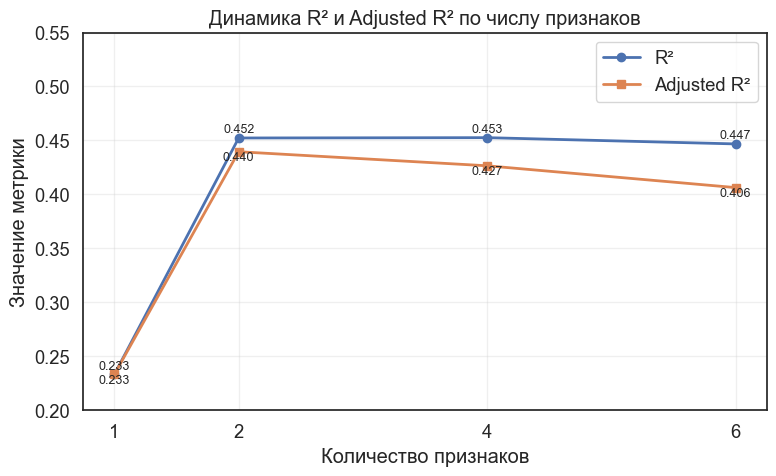

In [96]:
n_features = [1, 2, 4, 6]
r2_vals = [r2_1_f_test, r2_2_f_test, r2_4_f_test, r2_6_f_test]
adj_r2_vals = [
    r2_1_f_test,
    r2_adj_2,
    r2_adj_4,
    r2_adj_6,    
]
plt.figure(figsize=(8, 5))
plt.plot(n_features, r2_vals, marker="o", linewidth=2, label="R²")
plt.plot(n_features, adj_r2_vals, marker="s", linewidth=2, label="Adjusted R²")
# подписи точек
for x_cor, y_cor in zip(n_features, r2_vals):
    plt.text(x_cor, y_cor + 0.005, f"{y_cor:.3f}", ha="center", fontsize=9)
for x_cor, y_cor in zip(n_features, adj_r2_vals):
    plt.text(x_cor, y_cor - 0.008, f"{y_cor:.3f}", ha="center", fontsize=9)
plt.title("Динамика R² и Adjusted R² по числу признаков")
plt.xlabel("Количество признаков")
plt.ylabel("Значение метрики")
plt.xticks(n_features)
plt.ylim(0.2, 0.55)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Выводы:** как видно из сравнения моделей увеличение признаков больше 2 приводит к переобучению модели и не дает качественных улучшений прогноза. Самой оптимальной моделью можно считать ту, что построена по 2 признакам (bmi (индекс массы тела) и s5 (логарифм уровня триглицеридов в сыворотке крови)). Она дает объясняет около 45% разброса целевых значений. Можно сказать, что модель улавливает тренд, но, примерно, в половине случаев ошибается.

Модель составлена Васильевым Дмитрием в рамках курса ML Олега Булыгина на основе открытых учебных данных по [диабету](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html), 05.2026.